In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
from google.colab import files

uploaded = files.upload()


Saving CarPrice.csv to CarPrice.csv


In [ ]:
import pandas as pd

df = pd.read_csv("CarPrice.csv")

df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [ ]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving CarPrice.csv to CarPrice (1).csv


In [ ]:
import pandas as pd

df = pd.read_csv("/content/CarPrice (1).csv")

df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [ ]:
import pandas as pd

df = pd.read_csv("/content/CarPrice (1).csv")

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (205, 26)

Column Names:
['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price']

First 5 Rows:


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)
df.describe()
for col in df.select_dtypes(include='object').columns:
    print("\n", col)
    print(df[col].unique())


Number of duplicate rows: 0
Shape after removing duplicates: (205, 26)

 CarName
['alfa-romero giulia' 'alfa-romero stelvio' 'alfa-romero Quadrifoglio'
 'audi 100 ls' 'audi 100ls' 'audi fox' 'audi 5000' 'audi 4000'
 'audi 5000s (diesel)' 'bmw 320i' 'bmw x1' 'bmw x3' 'bmw z4' 'bmw x4'
 'bmw x5' 'chevrolet impala' 'chevrolet monte carlo' 'chevrolet vega 2300'
 'dodge rampage' 'dodge challenger se' 'dodge d200' 'dodge monaco (sw)'
 'dodge colt hardtop' 'dodge colt (sw)' 'dodge coronet custom'
 'dodge dart custom' 'dodge coronet custom (sw)' 'honda civic'
 'honda civic cvcc' 'honda accord cvcc' 'honda accord lx'
 'honda civic 1500 gl' 'honda accord' 'honda civic 1300' 'honda prelude'
 'honda civic (auto)' 'isuzu MU-X' 'isuzu D-Max ' 'isuzu D-Max V-Cross'
 'jaguar xj' 'jaguar xf' 'jaguar xk' 'maxda rx3' 'maxda glc deluxe'
 'mazda rx2 coupe' 'mazda rx-4' 'mazda glc deluxe' 'mazda 626' 'mazda glc'
 'mazda rx-7 gs' 'mazda glc 4' 'mazda glc custom l' 'mazda glc custom'
 'buick electra 225 custo

In [ ]:
# Check all categorical columns and their unique values

for col in df.select_dtypes(include='object').columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- CarName ---
CarName
peugeot 504                 6
toyota corolla              6
toyota corona               6
subaru dl                   4
mitsubishi outlander        3
                           ..
volkswagen super beetle     1
volkswagen rabbit custom    1
volvo 245                   1
volvo diesel                1
volvo 246                   1
Name: count, Length: 147, dtype: int64

--- fueltype ---
fueltype
gas       185
diesel     20
Name: count, dtype: int64

--- aspiration ---
aspiration
std      168
turbo     37
Name: count, dtype: int64

--- doornumber ---
doornumber
four    115
two      90
Name: count, dtype: int64

--- carbody ---
carbody
sedan          96
hatchback      70
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64

--- drivewheel ---
drivewheel
fwd    120
rwd     76
4wd      9
Name: count, dtype: int64

--- enginelocation ---
enginelocation
front    202
rear       3
Name: count, dtype: int64

--- enginetype ---
enginetype
ohc     

In [ ]:
# Remove leading/trailing spaces from text columns

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

In [ ]:
# Extract the car brand from CarName

df['Brand'] = df['CarName'].str.split().str[0]

df[['CarName', 'Brand']].head(10)

,CarName,Brand
0,alfa-romero giulia,alfa-romero
1,alfa-romero stelvio,alfa-romero
2,alfa-romero Quadrifoglio,alfa-romero
3,audi 100 ls,audi
4,audi 100ls,audi
5,audi fox,audi
6,audi 100ls,audi
7,audi 5000,audi
8,audi 4000,audi
9,audi 5000s (diesel),audi


In [ ]:
df.isnull().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Duplicate rows: 0
Shape after removing duplicates: (205, 27)


In [ ]:
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print("\n", col)
    print(df[col].value_counts())


 CarName
CarName
peugeot 504                 6
toyota corolla              6
toyota corona               6
subaru dl                   4
mitsubishi outlander        3
                           ..
volkswagen super beetle     1
volkswagen rabbit custom    1
volvo 245                   1
volvo diesel                1
volvo 246                   1
Name: count, Length: 147, dtype: int64

 fueltype
fueltype
gas       185
diesel     20
Name: count, dtype: int64

 aspiration
aspiration
std      168
turbo     37
Name: count, dtype: int64

 doornumber
doornumber
four    115
two      90
Name: count, dtype: int64

 carbody
carbody
sedan          96
hatchback      70
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64

 drivewheel
drivewheel
fwd    120
rwd     76
4wd      9
Name: count, dtype: int64

 enginelocation
enginelocation
front    202
rear       3
Name: count, dtype: int64

 enginetype
enginetype
ohc      148
ohcf      15
ohcv      13
dohc      12
l         12

In [ ]:
df['Brand'] = df['CarName'].str.split().str[0]

In [ ]:
brand_corrections = {
    'maxda': 'mazda',
    'porcshce': 'porsche',
    'toyouta': 'toyota',
    'vokswagen': 'volkswagen',
    'vw': 'volkswagen'
}

df['Brand'] = df['Brand'].replace(brand_corrections)

In [ ]:
df[['CarName', 'Brand']].head(10)

,CarName,Brand
0,alfa-romero giulia,alfa-romero
1,alfa-romero stelvio,alfa-romero
2,alfa-romero Quadrifoglio,alfa-romero
3,audi 100 ls,audi
4,audi 100ls,audi
5,audi fox,audi
6,audi 100ls,audi
7,audi 5000,audi
8,audi 4000,audi
9,audi 5000s (diesel),audi


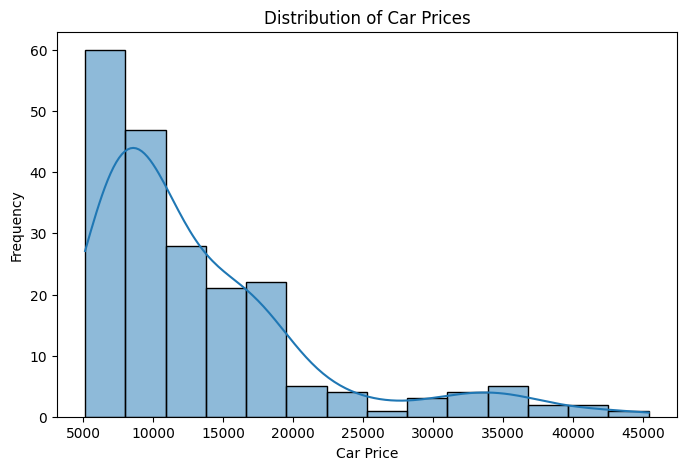

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df['price'], kde=True)

plt.title('Distribution of Car Prices')
plt.xlabel('Car Price')
plt.ylabel('Frequency')

plt.show()

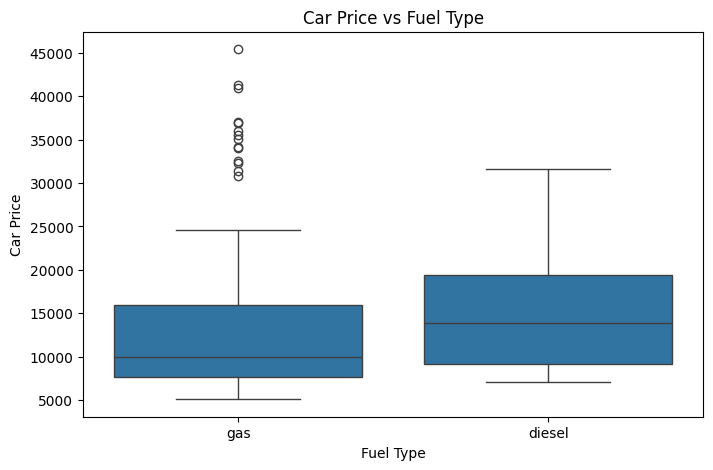

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='fueltype', y='price')

plt.title('Car Price vs Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Car Price')

plt.show()


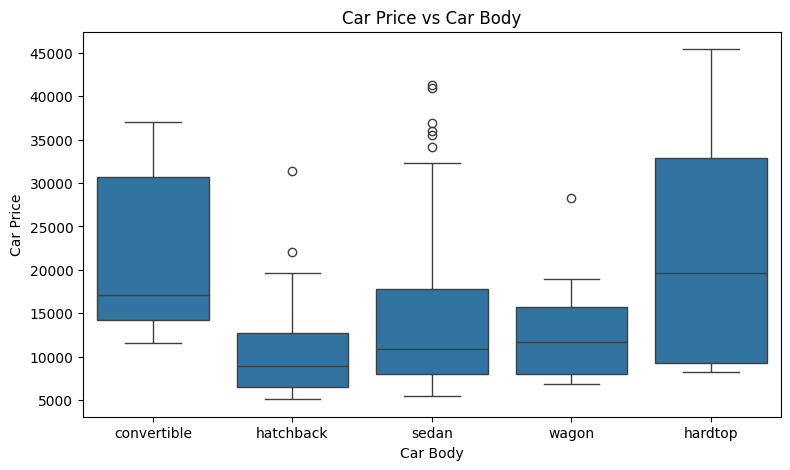

In [ ]:
plt.figure(figsize=(9,5))

sns.boxplot(data=df, x='carbody', y='price')

plt.title('Car Price vs Car Body')
plt.xlabel('Car Body')
plt.ylabel('Car Price')

plt.show()

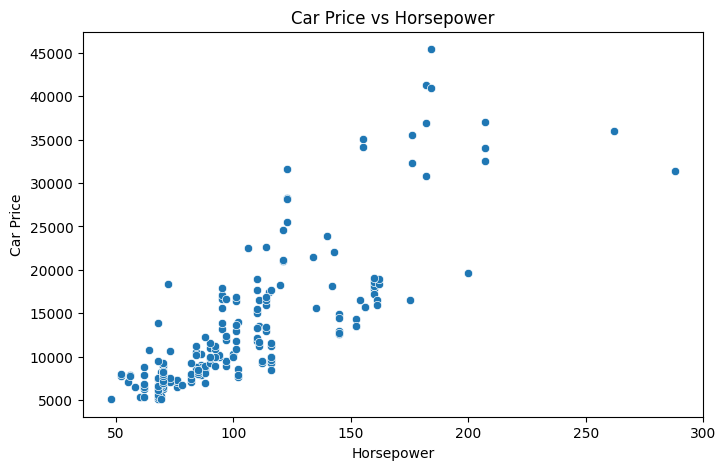

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x='horsepower', y='price')

plt.title('Car Price vs Horsepower')
plt.xlabel('Horsepower')
plt.ylabel('Car Price')

plt.show()

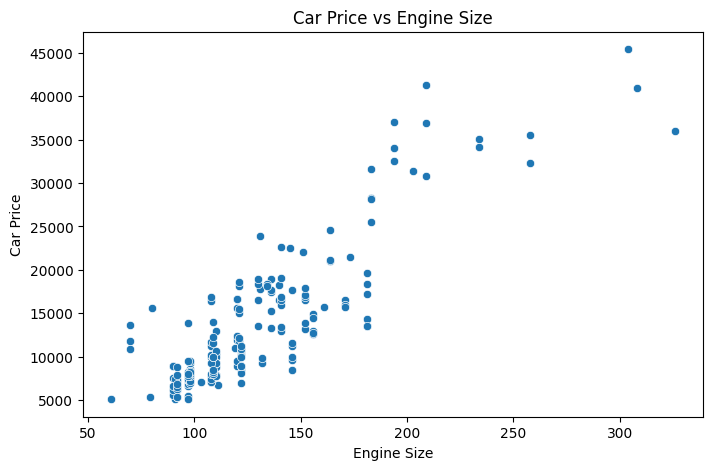

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x='enginesize', y='price')

plt.title('Car Price vs Engine Size')
plt.xlabel('Engine Size')
plt.ylabel('Car Price')

plt.show()

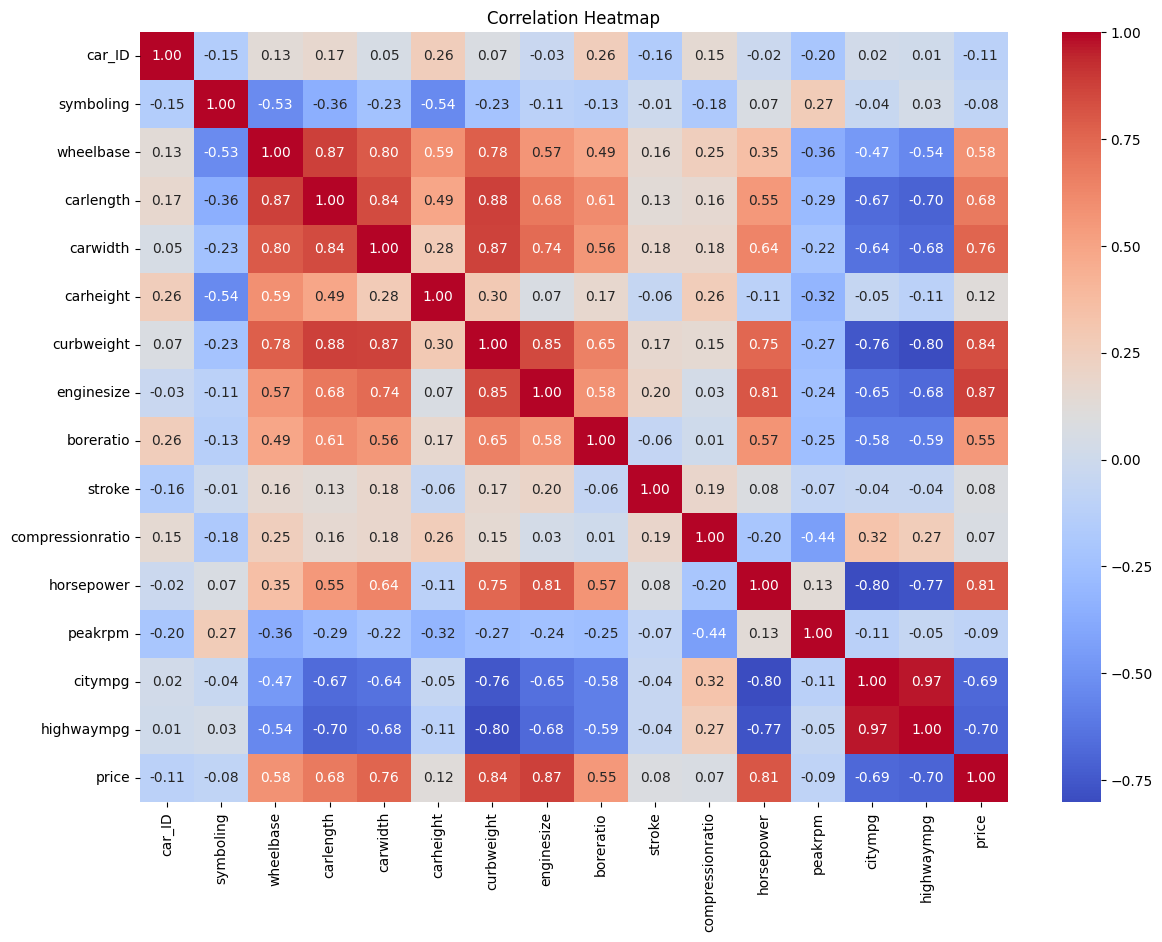

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

In [34]:
model_df = df.copy()
model_df = model_df.drop(columns=['CarName'])
model_df = model_df.drop(columns=['car_ID'])

In [36]:
X = model_df.drop(columns=['price'])
y = model_df['price']
print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['symboling', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'Brand']

Target:
price


In [37]:
categorical_columns = X.select_dtypes(include=['object']).columns
numerical_columns = X.select_dtypes(exclude=['object']).columns

print("Categorical columns:")
print(categorical_columns.tolist())

print("\nNumerical columns:")
print(numerical_columns.tolist())

Categorical columns:
['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem', 'Brand']

Numerical columns:
['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg']


In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ('categorical',
         OneHotEncoder(handle_unknown='ignore'),
         categorical_columns)
    ],
    remainder='passthrough'
)

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [42]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (164, 24)
Testing data: (41, 24)


In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

In [44]:
linear_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

In [45]:
linear_model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel',
       'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem',
       'Brand'],
      dtype='object'))])),
                ('model', LinearRegression())])

In [46]:
y_pred_linear = linear_model.predict(X_test)

In [47]:
from sklearn.ensemble import RandomForestRegressor

In [48]:
rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=200,
            random_state=42
        ))
    ]
)

In [49]:
rf_model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel',
       'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem',
       'Brand'],
      dtype='object'))])),
                ('model',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [50]:
y_pred_rf = rf_model.predict(X_test)

In [51]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

In [52]:
def evaluate_model(name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    print(name)
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R²  :", r2)
    print("-" * 40)

In [53]:
evaluate_model(
    "Linear Regression",
    y_test,
    y_pred_linear
)

evaluate_model(
    "Random Forest Regression",
    y_test,
    y_pred_rf
)

Linear Regression
MAE : 1807.9773050312651
RMSE: 2792.852098501346
R²  : 0.9011955211149717
----------------------------------------
Random Forest Regression
MAE : 1269.042837398374
RMSE: 1803.79910834354
R²  : 0.9587848302251937
----------------------------------------


In [54]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest Regression'
    ],

    'MAE': [
        mean_absolute_error(y_test, y_pred_linear),
        mean_absolute_error(y_test, y_pred_rf)
    ],

    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_linear)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ],

    'R2 Score': [
        r2_score(y_test, y_pred_linear),
        r2_score(y_test, y_pred_rf)
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1807.977305,2792.852099,0.901196
1,Random Forest Regression,1269.042837,1803.799108,0.958785


In [55]:
rf = rf_model.named_steps['model']

preprocessor_fitted = rf_model.named_steps['preprocessor']

feature_names = preprocessor_fitted.get_feature_names_out()

importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

In [56]:
feature_importance.head(15)

,Feature,Importance
66,remainder__enginesize,0.583730
65,remainder__curbweight,0.269542
73,remainder__highwaympg,0.042499
70,remainder__horsepower,0.022903
63,remainder__carwidth,0.012667
62,remainder__carlength,0.008810
40,categorical__Brand_bmw,0.007176
61,remainder__wheelbase,0.007104
72,remainder__citympg,0.006230
71,remainder__peakrpm,0.005492


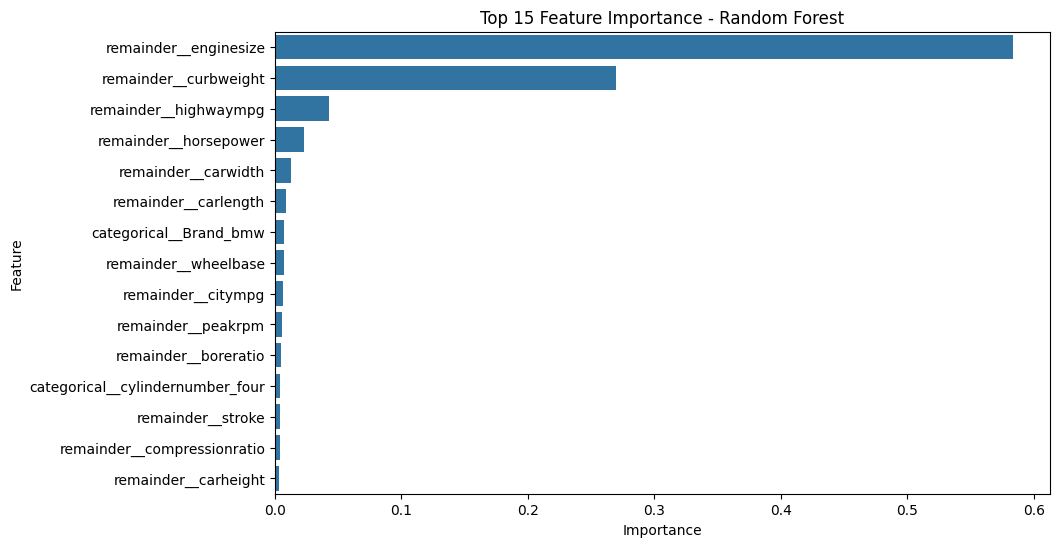

In [57]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title('Top 15 Feature Importance - Random Forest')

plt.show()

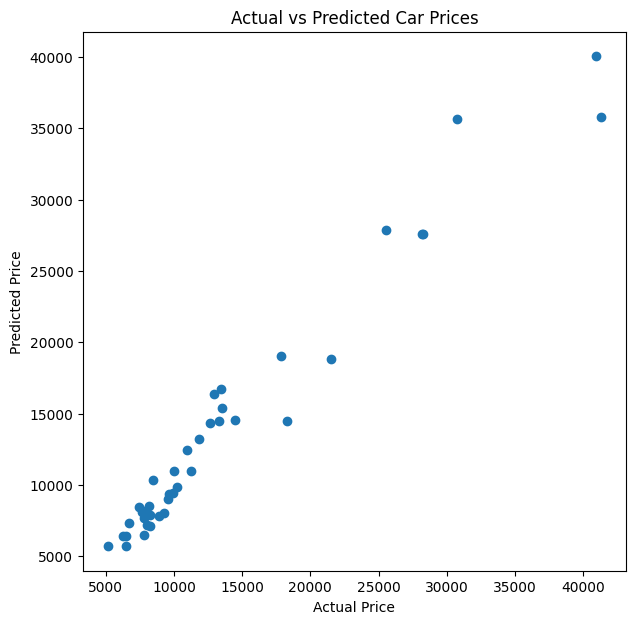

In [58]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred_rf)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Car Prices')

plt.show()

In [59]:
sample = X_test.iloc[[0]]

predicted_price = rf_model.predict(sample)[0]

actual_price = y_test.iloc[0]

print("Actual Price:", actual_price)
print("Predicted Price:", predicted_price)

Actual Price: 30760.0
Predicted Price: 35689.8375
